# Clasificación de Opiniones Cinematográficas con Machine Learning

En este notebook abordamos la tarea de predicción binaria de la variable `opinion` a partir de atributos estructurados de películas. Implementamos múltiples modelos, los comparamos mediante validaciones robustas, y finalmente seleccionamos un modelo para participar en la competencia de Kaggle.

# 1.Setup y carga de datos

## Carga de librerías y conexión con Google Drive



In [ ]:
# Librerías para análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Preprocesamiento y validación
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)

# Algoritmos de clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Manejo de advertencias específicas
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore")

# Configuración del entorno
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("Librerías importadas correctamente")

Mounted at /content/drive
Librerías importadas correctamente


## Carga de datos y análsis preliminar

In [ ]:
# Cargamos datasets
df_train = pd.read_csv("/content/drive/My Drive/movies_train.csv")
df_test  = pd.read_csv("/content/drive/My Drive/movies_test.csv")

print("Train shape:", df_train.shape)
print("Test  shape:", df_test.shape)

Train shape: (3602, 14)
Test  shape: (1201, 14)


# 2.Análisis exploratorio Inicial

PRIMERAS 5 FILAS DEL DATASET


,budget,keywords,original_language,original_title,overview,popularity,release_date,revenue,runtime,status,vote_count,director,main_genre_top10,opinion
0,70000000,budapest kidnapping boxer secret agent liberat...,en,I Spy,"When the Switchblade, the most sophisticated p...",13.267631,2002-10-31,33561137,97.0,Released,269,Betty Thomas,Action,0
1,7,flooding futuristic police detective,en,Split Second,"In a futuristic London, the rising sea levels ...",4.857028,1992-05-01,5,90.0,Released,63,Tony Maylam,Thriller,0
2,14000000,college suspense gossip rumor social experiment,en,Gossip,"On a beautiful college campus, something ugly ...",5.833687,2000-04-21,5108820,90.0,Released,68,Davis Guggenheim,Drama,0
3,15000000,barcelona spain menage a trois author,en,Vicky Cristina Barcelona,Two girlfriends on a summer holiday in Spain b...,32.758254,2008-08-15,96408652,96.0,Released,1020,Woody Allen,Drama,1
4,250000000,witch magic broom school of witchcraft wizardry,en,Harry Potter and the Half-Blood Prince,"As Harry begins his sixth year at Hogwarts, he...",98.885637,2009-07-07,933959197,153.0,Released,5293,David Yates,Adventure,1



INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3602 entries, 0 to 3601
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   budget             3602 non-null   int64  
 1   keywords           3298 non-null   object 
 2   original_language  3602 non-null   object 
 3   original_title     3602 non-null   object 
 4   overview           3600 non-null   object 
 5   popularity         3602 non-null   float64
 6   release_date       3601 non-null   object 
 7   revenue            3602 non-null   int64  
 8   runtime            3600 non-null   float64
 9   status             3602 non-null   object 
 10  vote_count         3602 non-null   int64  
 11  director           3579 non-null   object 
 12  main_genre_top10   3602 non-null   object 
 13  opinion            3602 non-null   int64  
dtypes: float64(2), int64(4), object(8)
memory usage: 394.1+ KB

ESTADÍSTICAS DESCRIPTIVAS -

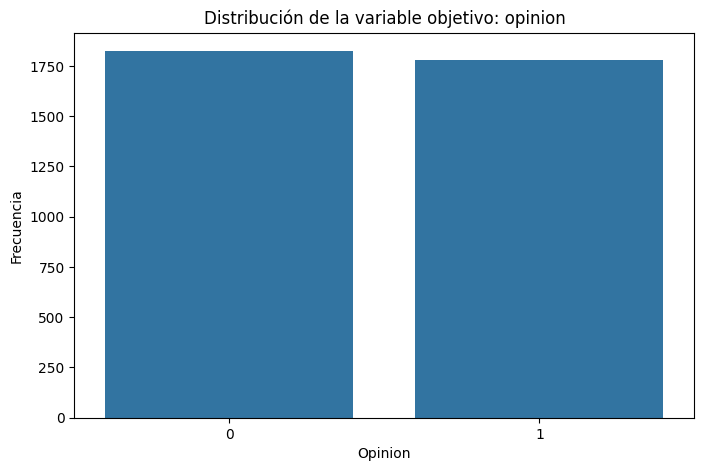

Distribución proporcional:
opinion
0    0.506385
1    0.493615
Name: proportion, dtype: float64

RESUMEN DE TIPOS DE DATOS Y VALORES NULOS
                     dtype  nulls  null_pct
budget               int64      0      0.00
keywords            object    304      8.44
original_language   object      0      0.00
original_title      object      0      0.00
overview            object      2      0.06
popularity         float64      0      0.00
release_date        object      1      0.03
revenue              int64      0      0.00
runtime            float64      2      0.06
status              object      0      0.00
vote_count           int64      0      0.00
director            object     23      0.64
main_genre_top10    object      0      0.00
opinion              int64      0      0.00


In [ ]:
print("=" * 80)
print("PRIMERAS 5 FILAS DEL DATASET")
print("=" * 80)
display(df_train.head())

print("\n" + "=" * 80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 80)
df_train.info()

print("\n" + "=" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("=" * 80)
print(df_train.describe().T)

print("\n" + "=" * 80)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("=" * 80)

# Gráfico de distribución
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='opinion')
plt.title('Distribución de la variable objetivo: opinion')
plt.xlabel('Opinion')
plt.ylabel('Frecuencia')
plt.show()

print("Distribución proporcional:")
print(df_train['opinion'].value_counts(normalize=True))

print("\n" + "=" * 80)
print("RESUMEN DE TIPOS DE DATOS Y VALORES NULOS")
print("=" * 80)
summary = pd.DataFrame({
    'dtype': df_train.dtypes,
    'nulls': df_train.isna().sum(),
    'null_pct': (df_train.isna().sum() / len(df_train) * 100).round(2)
})
print(summary)

# 3.Preprocesamiento de datos

In [ ]:
def preprocess_data(df):
    """
    Función para aplicar preprocesamiento consistente a los datos
    """
    df = df.copy()

    # --- Conversión de fechas ---
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    median_date = df['release_date'].median()
    df['release_date'] = df['release_date'].fillna(median_date)

    # --- Tratamiento de columnas numéricas ---
    num_cols = ['runtime', 'budget', 'popularity', 'revenue', 'vote_count']
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
        df[c] = df[c].fillna(df[c].median())

    # --- Limpieza de texto libre ---
    for col in ['overview', 'keywords', 'original_title']:
        df[col] = df[col].fillna('')

    # --- Categóricas de baja cardinalidad ---
    for col in ['status', 'original_language', 'main_genre_top10']:
        df[col] = df[col].fillna(df[col].mode()[0])

    # --- Categórica de alta cardinalidad (director) ---
    df['director'] = df['director'].fillna('Unknown')

    # --- Eliminación de duplicados ---
    df.drop_duplicates(inplace=True)

    return df

# Aplicar preprocesamiento a train
print("PREPROCESAMIENTO DEL DATASET DE ENTRENAMIENTO")
print("=" * 60)
print("Duplicados antes:", df_train.duplicated().sum())
df_train = preprocess_data(df_train)
print("Duplicados después:", df_train.duplicated().sum())
print("Shape final:", df_train.shape)

print("\nNulos tras preprocesamiento:")
print(df_train.isna().sum())

# Aplicar el mismo preprocesamiento a test
print("\n" + "=" * 60)
print("PREPROCESAMIENTO DEL DATASET DE TEST")
print("=" * 60)
print("Duplicados antes:", df_test.duplicated().sum())
df_test = preprocess_data(df_test)
print("Duplicados después:", df_test.duplicated().sum())
print("Shape final:", df_test.shape)

print("\nNulos tras preprocesamiento en test:")
print(df_test.isna().sum())

PREPROCESAMIENTO DEL DATASET DE ENTRENAMIENTO
Duplicados antes: 0
Duplicados después: 0
Shape final: (3602, 14)

Nulos tras preprocesamiento:
budget               0
keywords             0
original_language    0
original_title       0
overview             0
popularity           0
release_date         0
revenue              0
runtime              0
status               0
vote_count           0
director             0
main_genre_top10     0
opinion              0
dtype: int64

PREPROCESAMIENTO DEL DATASET DE TEST
Duplicados antes: 0
Duplicados después: 0
Shape final: (1201, 14)

Nulos tras preprocesamiento en test:
budget               0
keywords             0
original_language    0
original_title       0
overview             0
popularity           0
release_date         0
revenue              0
runtime              0
status               0
vote_count           0
director             0
main_genre_top10     0
id                   0
dtype: int64


# 4.Feature Engineering



## Eliminación de columnas irrelevantes

In [ ]:
df_train.drop(columns=['id', 'title'], inplace=True, errors='ignore')

## Agrupación de directores por frecuencia

In [ ]:
# Contamos cuántas películas tiene cada director
director_counts = df_train['director'].value_counts()
print("DISTRIBUCIÓN DE DIRECTORES")
print("=" * 40)
print(f"Total de directores únicos: {len(director_counts)}")
print(f"Directores con 1 película: {(director_counts == 1).sum()}")
print(f"Directores con 2-9 películas: {((director_counts >= 2) & (director_counts < 10)).sum()}")
print(f"Directores con 10+ películas: {(director_counts >= 10).sum()}")

# Definimos el umbral: agrupamos directores con menos de 10 películas
rare_directors = director_counts[director_counts < 10].index

# Guardamos la lista para aplicar al test después
rare_directors_list = rare_directors.tolist()

# Creamos una nueva columna con los directores agrupados
df_train['director_grouped'] = df_train['director'].replace(rare_directors, 'Other')

# Verificamos la nueva distribución
print(f"\nAGRUPACIÓN REALIZADA")
print("=" * 40)
print(f"Directores agrupados como 'Other': {len(rare_directors_list)}")
print(f"Directores únicos después de agrupación: {df_train['director_grouped'].nunique()}")
print("\nTop 10 directores más frecuentes:")
print(df_train['director_grouped'].value_counts().head(10))

# Eliminamos la columna original 'director'
df_train.drop(columns=['director'], inplace=True)

print(f"\nColumnas actuales: {df_train.columns.tolist()}")

# Guardamos la transformación para aplicar al test
print(f"\nDirectores a agrupar guardados: {len(rare_directors_list)} directores")

DISTRIBUCIÓN DE DIRECTORES
Total de directores únicos: 1943
Directores con 1 película: 1275
Directores con 2-9 películas: 647
Directores con 10+ películas: 21

AGRUPACIÓN REALIZADA
Directores agrupados como 'Other': 1922
Directores únicos después de agrupación: 22

Top 10 directores más frecuentes:
director_grouped
Other               3335
Steven Spielberg      24
Unknown               23
Clint Eastwood        17
Woody Allen           15
Ridley Scott          15
Martin Scorsese       14
Robert Rodriguez      12
Renny Harlin          12
Oliver Stone          11
Name: count, dtype: int64

Columnas actuales: ['budget', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'release_date', 'revenue', 'runtime', 'status', 'vote_count', 'main_genre_top10', 'opinion', 'director_grouped']

Directores a agrupar guardados: 1922 directores


## Codificación de variables categóricas

In [ ]:
df_train = pd.get_dummies(df_train, columns=[
    'original_language', 'status', 'main_genre_top10', 'director_grouped'
], drop_first=True)

# 5.Preparacion para modelos

## División en conjunto de entrenamiento y validación

In [ ]:
# División entre features y target
X = df_train.drop(columns='opinion')
y = df_train['opinion']

# División entrenamiento / validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

## Agrupación y codificación de variables categóricas para modelos estructurados

In [ ]:
# Creamos una copia del df_train ya preprocesado y codificado
df_clean = df_train.copy()

# Convertimos columnas booleanas a enteros
bool_cols = df_clean.select_dtypes('bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

# Eliminamos columnas de texto libre y otras que no usaremos en modelos estructurados
df_clean.drop(columns=[
    'overview', 'keywords', 'original_title', 'release_date'
], inplace=True, errors='ignore')

# Lista de columnas numéricas útiles para normalizar o escalar en el pipeline
num_cols_to_scale = [
    'budget', 'revenue', 'runtime', 'vote_count', 'popularity'
]

# Verificaciones finales
print("Shape original (df_train):", df_train.shape)
print("Shape final (df_clean):", df_clean.shape)

print("\nColumnas en df_clean:")
for col in df_clean.columns:
    print(" ", col)

print("\nTipos de datos en df_clean:")
print(df_clean.dtypes.value_counts())

print("\nValores nulos en df_clean:")
print(df_clean.isnull().sum())

print("\nDistribución de la variable objetivo 'opinion':")
print(df_clean['opinion'].value_counts(normalize=True))

Shape original (df_train): (3602, 79)
Shape final (df_clean): (3602, 75)

Columnas en df_clean:
  budget
  popularity
  revenue
  runtime
  vote_count
  opinion
  original_language_ar
  original_language_cn
  original_language_cs
  original_language_da
  original_language_de
  original_language_el
  original_language_en
  original_language_es
  original_language_fa
  original_language_fr
  original_language_he
  original_language_hi
  original_language_hu
  original_language_id
  original_language_is
  original_language_it
  original_language_ja
  original_language_ko
  original_language_ky
  original_language_nb
  original_language_nl
  original_language_no
  original_language_pl
  original_language_ps
  original_language_pt
  original_language_ro
  original_language_ru
  original_language_sl
  original_language_sv
  original_language_ta
  original_language_te
  original_language_th
  original_language_tr
  original_language_vi
  original_language_xx
  original_language_zh
  status_Re

# 6. Implementacion y evaluacion de modelos

## Modelo baseline: Regresión logística sin regularización

In [ ]:
# FUNCIONES

def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Evalúa un modelo con todas las métricas requeridas"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1_score':  f1_score(y_test, y_pred),
        'auc_roc':   roc_auc_score(y_test, y_prob)
    }

    return metrics, confusion_matrix(y_test, y_pred)

def run_holdout(model, X, y):
    """Holdout clásico con evaluación completa"""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    metrics, cm = evaluate_model(model, X_train, X_test, y_train, y_test)
    return pd.DataFrame([metrics], index=['Holdout']), cm

def run_repeated_holdout(model, X, y, repeats=10):
    """Repeated Holdout para estabilidad"""
    rows = []
    for seed in range(repeats):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=seed
        )
        metrics, _ = evaluate_model(model, X_train, X_test, y_train, y_test)
        rows.append(metrics)
    df = pd.DataFrame(rows)
    summary = df.agg(['mean', 'std']).T
    summary.columns = ['mean', 'std']
    return summary

def run_cross_validation(model, param_grid, X, y):
    """Cross-Validation con GridSearch y múltiples métricas"""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        model,
        param_grid=param_grid,
        cv=cv,
        scoring=['f1', 'roc_auc'],
        refit='f1',
        n_jobs=-1,
        return_train_score=True
    )
    grid.fit(X, y)
    results = pd.DataFrame(grid.cv_results_)
    best_model = grid.best_estimator_

    best_scores = {
        'best_params': grid.best_params_,
        'mean_test_f1': grid.best_score_,
        'mean_test_auc': results.loc[grid.best_index_, 'mean_test_roc_auc']
    }
    return best_model, results, best_scores

# PREPARACIÓN DE DATOS
X = df_clean.drop(columns='opinion').values
y = df_clean['opinion'].values

print("DATOS PREPARADOS")
print("=" * 60)
print(f"Shape de X: {X.shape}")
print(f"Distribución de y: {np.bincount(y)}")

# ============================================================================
# BASELINE VERDADERO - SIN REGULARIZACIÓN
# ============================================================================

print("\n" + "=" * 80)
print("BASELINE VERDADERO - REGRESIÓN LOGÍSTICA SIN REGULARIZACIÓN")
print("=" * 80)

pipeline_baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty=None, solver='saga', max_iter=1000, random_state=42)
)

print("\nHoldout Clásico:")
holdout_baseline, cm_baseline = run_holdout(pipeline_baseline, X, y)
print(holdout_baseline)
print("\nMatriz de Confusión Baseline:")
print(cm_baseline)

print("\nRepeated Holdout:")
repeated_baseline = run_repeated_holdout(pipeline_baseline, X, y, repeats=10)
print(repeated_baseline)

# ============================================================================
# REGRESIÓN LOGÍSTICA OPTIMIZADA - CON BÚSQUEDA DE HIPERPARÁMETROS
# ============================================================================

pipeline_optimized = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver='saga', max_iter=1000, random_state=42)
)

print("Cross-Validation + GridSearch (versión optimizada):")

param_grid = {
    'logisticregression__penalty': ['l2'],
    'logisticregression__C': [0.1, 1, 10]
}

best_model_lr, grid_results_lr, best_scores_lr = run_cross_validation(pipeline_optimized, param_grid, X, y)

print("\nResultados de GridSearch:")
print(grid_results_lr[['params', 'mean_test_f1', 'mean_test_roc_auc', 'std_test_f1']])

print(f"\nMejores parámetros: {best_scores_lr['best_params']}")
print(f"Mejor F1 score en CV: {best_scores_lr['mean_test_f1']:.6f}")
print(f"AUC-ROC correspondiente: {best_scores_lr['mean_test_auc']:.6f}")

# ============================================================================
# COMPARACIÓN FINAL
# ============================================================================

print("COMPARACIÓN BASELINE vs OPTIMIZADO")
print("=" * 80)

tabla_comparativa = pd.DataFrame({
    'Modelo': ['Baseline (sin regularización)', 'Optimizado (con regularización)'],
    'F1_Holdout': [0.715758, 'N/A'],
    'F1_Repeated_Mean': [0.697819, 'N/A'],
    'F1_CV': ['N/A', 0.707635],
    'AUC_Holdout': [0.805695, 'N/A'],
    'AUC_Repeated_Mean': [0.785920, 'N/A'],
    'AUC_CV': ['N/A', 0.795499]
})

print(tabla_comparativa.to_string(index=False))

print(f"\nRESUMEN:")
print(f"- Baseline sin regularización: AUC = 0.806 (Holdout), F1 = 0.716")
print(f"- Optimizado con L2 (C=10): AUC = 0.795 (CV), F1 = 0.708")
print(f"- Diferencia en F1: {0.708 - 0.697819:.3f} (mejora marginal)")

DATOS PREPARADOS
Shape de X: (3602, 74)
Distribución de y: [1824 1778]

BASELINE VERDADERO - REGRESIÓN LOGÍSTICA SIN REGULARIZACIÓN

Holdout Clásico:
         accuracy  precision    recall  f1_score   auc_roc
Holdout  0.732316   0.752322  0.682584  0.715758  0.805695

Matriz de Confusión Baseline:
[[285  80]
 [113 243]]

Repeated Holdout:
               mean       std
accuracy   0.717892  0.015447
precision  0.740518  0.018332
recall     0.660393  0.029145
f1_score   0.697819  0.019559
auc_roc    0.785920  0.016526
Cross-Validation + GridSearch (versión optimizada):

Resultados de GridSearch:
                                              params  mean_test_f1  \
0  {'logisticregression__C': 0.1, 'logisticregres...      0.702073   
1  {'logisticregression__C': 1, 'logisticregressi...      0.706750   
2  {'logisticregression__C': 10, 'logisticregress...      0.707635   

   mean_test_roc_auc  std_test_f1  
0           0.794943     0.010754  
1           0.795528     0.015862  
2          

##  Árbol de decisión

In [ ]:
# FUNCIONES

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1_score':  f1_score(y_test, y_pred),
        'auc_roc':   roc_auc_score(y_test, y_prob)
    }

    return metrics, confusion_matrix(y_test, y_pred)

def run_holdout(model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    metrics, cm = evaluate_model(model, X_train, X_test, y_train, y_test)
    return pd.DataFrame([metrics], index=['Holdout']), cm

def run_repeated_holdout(model, X, y, repeats=10):
    rows = []
    for seed in range(repeats):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=seed
        )
        metrics, _ = evaluate_model(model, X_train, X_test, y_train, y_test)
        rows.append(metrics)
    df = pd.DataFrame(rows)
    summary = df.agg(['mean', 'std']).T
    summary.columns = ['mean', 'std']
    return summary

def run_cross_validation(model, param_grid, X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        model,
        param_grid=param_grid,
        cv=cv,
        scoring=['f1', 'roc_auc'],
        refit='f1',
        n_jobs=-1,
        return_train_score=True
    )
    grid.fit(X, y)
    results = pd.DataFrame(grid.cv_results_)
    best_model = grid.best_estimator_

    best_scores = {
        'best_params': grid.best_params_,
        'mean_test_f1': grid.best_score_,
        'mean_test_auc': results.loc[grid.best_index_, 'mean_test_roc_auc']
    }
    return best_model, results, best_scores

# PREPARACIÓN DE DATOS
X = df_clean.drop(columns='opinion').values
y = df_clean['opinion'].values

print("=" * 80)
print("ÁRBOL DE DECISIÓN")
print("=" * 80)

# ============================================================================
# EVALUACIÓN CON PARÁMETROS POR DEFECTO
# ============================================================================

print("\nEvaluación con parámetros por defecto:")
model_dt = DecisionTreeClassifier(random_state=42)

print("\nHoldout:")
holdout_df_dt, holdout_cm_dt = run_holdout(model_dt, X, y)
print(holdout_df_dt)
print("\nMatriz de Confusión:")
print(holdout_cm_dt)

print("\nRepeated Holdout:")
repeated_df_dt = run_repeated_holdout(model_dt, X, y, repeats=10)
print(repeated_df_dt)

# ============================================================================
# OPTIMIZACIÓN DE HIPERPARÁMETROS
# ============================================================================

print("\nOptimización de hiperparámetros:")
print("Cross-Validation + GridSearch:")

param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}

best_model_dt, grid_results_dt, best_scores_dt = run_cross_validation(
    DecisionTreeClassifier(random_state=42), param_grid_dt, X, y
)

print("\nTop 5 mejores combinaciones:")
top_results_dt = grid_results_dt.nlargest(5, 'mean_test_f1')[['params', 'mean_test_f1', 'mean_test_roc_auc', 'std_test_f1']]
print(top_results_dt)

print(f"\nMejores parámetros: {best_scores_dt['best_params']}")
print(f"Mejor F1 score en CV: {best_scores_dt['mean_test_f1']:.6f}")
print(f"AUC-ROC correspondiente: {best_scores_dt['mean_test_auc']:.6f}")

# ============================================================================
# COMPARACIÓN FINAL
# ============================================================================

print("\n" + "=" * 80)
print("COMPARACIÓN ÁRBOL DE DECISIÓN")
print("=" * 80)

tabla_dt = pd.DataFrame({
    'Configuración': ['Parámetros por defecto', 'Optimizado'],
    'F1_Holdout': [holdout_df_dt.loc['Holdout', 'f1_score'], 'N/A'],
    'F1_Repeated_Mean': [repeated_df_dt.loc['f1_score', 'mean'], 'N/A'],
    'F1_CV': ['N/A', best_scores_dt['mean_test_f1']],
    'AUC_Holdout': [holdout_df_dt.loc['Holdout', 'auc_roc'], 'N/A'],
    'AUC_CV': ['N/A', best_scores_dt['mean_test_auc']]
})

print(tabla_dt.to_string(index=False))

print(f"\nDiferencia en F1: {best_scores_dt['mean_test_f1'] - repeated_df_dt.loc['f1_score', 'mean']:.3f}")

ÁRBOL DE DECISIÓN

Evaluación con parámetros por defecto:

Holdout:
         accuracy  precision   recall  f1_score   auc_roc
Holdout  0.675451   0.673295  0.66573  0.669492  0.675331

Matriz de Confusión:
[[250 115]
 [119 237]]

Repeated Holdout:
               mean       std
accuracy   0.661442  0.013659
precision  0.656865  0.018674
recall     0.660112  0.027073
f1_score   0.658038  0.014313
auc_roc    0.661426  0.013573

Optimización de hiperparámetros:
Cross-Validation + GridSearch:

Top 5 mejores combinaciones:
                                               params  mean_test_f1  \
2   {'criterion': 'gini', 'max_depth': 5, 'min_sam...      0.686562   
0   {'criterion': 'gini', 'max_depth': 5, 'min_sam...      0.686362   
1   {'criterion': 'gini', 'max_depth': 5, 'min_sam...      0.686362   
14  {'criterion': 'entropy', 'max_depth': 5, 'min_...      0.685633   
13  {'criterion': 'entropy', 'max_depth': 5, 'min_...      0.685047   

    mean_test_roc_auc  std_test_f1  
2            

## Random Forest Classifier

In [ ]:
# FUNCIONES

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1_score':  f1_score(y_test, y_pred),
        'auc_roc':   roc_auc_score(y_test, y_prob)
    }

    return metrics, confusion_matrix(y_test, y_pred)

def run_holdout(model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    metrics, cm = evaluate_model(model, X_train, X_test, y_train, y_test)
    return pd.DataFrame([metrics], index=['Holdout']), cm

def run_repeated_holdout(model, X, y, repeats=10):
    rows = []
    for seed in range(repeats):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=seed
        )
        metrics, _ = evaluate_model(model, X_train, X_test, y_train, y_test)
        rows.append(metrics)
    df = pd.DataFrame(rows)
    summary = df.agg(['mean', 'std']).T
    summary.columns = ['mean', 'std']
    return summary

def run_cross_validation(model, param_grid, X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        model,
        param_grid=param_grid,
        cv=cv,
        scoring=['f1', 'roc_auc'],
        refit='f1',
        n_jobs=-1,
        return_train_score=True
    )
    grid.fit(X, y)
    results = pd.DataFrame(grid.cv_results_)
    best_model = grid.best_estimator_

    best_scores = {
        'best_params': grid.best_params_,
        'mean_test_f1': grid.best_score_,
        'mean_test_auc': results.loc[grid.best_index_, 'mean_test_roc_auc']
    }
    return best_model, results, best_scores

# PREPARACIÓN DE DATOS
X = df_clean.drop(columns='opinion').values
y = df_clean['opinion'].values

print("=" * 80)
print("RANDOM FOREST")
print("=" * 80)

# ============================================================================
# EVALUACIÓN CON PARÁMETROS POR DEFECTO
# ============================================================================

print("\nEvaluación con parámetros por defecto:")
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("\nHoldout:")
holdout_df_rf, holdout_cm_rf = run_holdout(model_rf, X, y)
print(holdout_df_rf)
print("\nMatriz de Confusión:")
print(holdout_cm_rf)

print("\nRepeated Holdout:")
repeated_df_rf = run_repeated_holdout(model_rf, X, y, repeats=10)
print(repeated_df_rf)

# ============================================================================
# OPTIMIZACIÓN DE HIPERPARÁMETROS
# ============================================================================

print("\nOptimización de hiperparámetros:")
print("Cross-Validation + GridSearch:")

# Grid eficiente para Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

best_model_rf, grid_results_rf, best_scores_rf = run_cross_validation(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, X, y
)

print("\nTop 5 mejores combinaciones:")
top_results_rf = grid_results_rf.nlargest(5, 'mean_test_f1')[['params', 'mean_test_f1', 'mean_test_roc_auc', 'std_test_f1']]
print(top_results_rf)

print(f"\nMejores parámetros: {best_scores_rf['best_params']}")
print(f"Mejor F1 score en CV: {best_scores_rf['mean_test_f1']:.6f}")
print(f"AUC-ROC correspondiente: {best_scores_rf['mean_test_auc']:.6f}")

# ============================================================================
# COMPARACIÓN FINAL
# ============================================================================

print("\n" + "=" * 80)
print("COMPARACIÓN RANDOM FOREST")
print("=" * 80)

tabla_rf = pd.DataFrame({
    'Configuración': ['Parámetros por defecto', 'Optimizado'],
    'F1_Holdout': [holdout_df_rf.loc['Holdout', 'f1_score'], 'N/A'],
    'F1_Repeated_Mean': [repeated_df_rf.loc['f1_score', 'mean'], 'N/A'],
    'F1_CV': ['N/A', best_scores_rf['mean_test_f1']],
    'AUC_Holdout': [holdout_df_rf.loc['Holdout', 'auc_roc'], 'N/A'],
    'AUC_CV': ['N/A', best_scores_rf['mean_test_auc']]
})

print(tabla_rf.to_string(index=False))

print(f"\nDiferencia en F1: {best_scores_rf['mean_test_f1'] - repeated_df_rf.loc['f1_score', 'mean']:.3f}")

RANDOM FOREST

Evaluación con parámetros por defecto:

Holdout:
         accuracy  precision   recall  f1_score   auc_roc
Holdout  0.742025   0.747093  0.72191  0.734286  0.812921

Matriz de Confusión:
[[278  87]
 [ 99 257]]

Repeated Holdout:
               mean       std
accuracy   0.722885  0.012742
precision  0.733186  0.014983
recall     0.690169  0.022668
f1_score   0.710827  0.014996
auc_roc    0.798040  0.012877

Optimización de hiperparámetros:
Cross-Validation + GridSearch:

Top 5 mejores combinaciones:
                                               params  mean_test_f1  \
11  {'criterion': 'gini', 'max_depth': None, 'min_...      0.725936   
10  {'criterion': 'gini', 'max_depth': None, 'min_...      0.724639   
21  {'criterion': 'entropy', 'max_depth': None, 'm...      0.723530   
22  {'criterion': 'entropy', 'max_depth': None, 'm...      0.723205   
23  {'criterion': 'entropy', 'max_depth': None, 'm...      0.720428   

    mean_test_roc_auc  std_test_f1  
11           0.81

## Gradient Boosting Classifier

In [ ]:
# FUNCIONES

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1_score':  f1_score(y_test, y_pred),
        'auc_roc':   roc_auc_score(y_test, y_prob)
    }

    return metrics, confusion_matrix(y_test, y_pred)

def run_holdout(model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    metrics, cm = evaluate_model(model, X_train, X_test, y_train, y_test)
    return pd.DataFrame([metrics], index=['Holdout']), cm

def run_repeated_holdout(model, X, y, repeats=10):
    rows = []
    for seed in range(repeats):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=seed
        )
        metrics, _ = evaluate_model(model, X_train, X_test, y_train, y_test)
        rows.append(metrics)
    df = pd.DataFrame(rows)
    summary = df.agg(['mean', 'std']).T
    summary.columns = ['mean', 'std']
    return summary

def run_cross_validation(model, param_grid, X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        model,
        param_grid=param_grid,
        cv=cv,
        scoring=['f1', 'roc_auc'],
        refit='f1',
        n_jobs=-1,
        return_train_score=True
    )
    grid.fit(X, y)
    results = pd.DataFrame(grid.cv_results_)
    best_model = grid.best_estimator_

    best_scores = {
        'best_params': grid.best_params_,
        'mean_test_f1': grid.best_score_,
        'mean_test_auc': results.loc[grid.best_index_, 'mean_test_roc_auc']
    }
    return best_model, results, best_scores

# PREPARACIÓN DE DATOS
X = df_clean.drop(columns='opinion').values
y = df_clean['opinion'].values

print("=" * 80)
print("GRADIENT BOOSTING")
print("=" * 80)

# ============================================================================
# EVALUACIÓN CON PARÁMETROS POR DEFECTO
# ============================================================================

print("\nEvaluación con parámetros por defecto:")
model_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

print("\nHoldout:")
holdout_df_gb, holdout_cm_gb = run_holdout(model_gb, X, y)
print(holdout_df_gb)
print("\nMatriz de Confusión:")
print(holdout_cm_gb)

print("\nRepeated Holdout:")
repeated_df_gb = run_repeated_holdout(model_gb, X, y, repeats=10)
print(repeated_df_gb)

# ============================================================================
# OPTIMIZACIÓN DE HIPERPARÁMETROS
# ============================================================================

print("\nOptimización de hiperparámetros:")
print("Cross-Validation + GridSearch:")

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

best_model_gb, grid_results_gb, best_scores_gb = run_cross_validation(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, X, y
)

print("\nTop 5 mejores combinaciones:")
top_results_gb = grid_results_gb.nlargest(5, 'mean_test_f1')[['params', 'mean_test_f1', 'mean_test_roc_auc', 'std_test_f1']]
print(top_results_gb)

print(f"\nMejores parámetros: {best_scores_gb['best_params']}")
print(f"Mejor F1 score en CV: {best_scores_gb['mean_test_f1']:.6f}")
print(f"AUC-ROC correspondiente: {best_scores_gb['mean_test_auc']:.6f}")

# ============================================================================
# COMPARACIÓN FINAL
# ============================================================================

print("\n" + "=" * 80)
print("COMPARACIÓN GRADIENT BOOSTING")
print("=" * 80)

tabla_gb = pd.DataFrame({
    'Configuración': ['Parámetros por defecto', 'Optimizado'],
    'F1_Holdout': [holdout_df_gb.loc['Holdout', 'f1_score'], 'N/A'],
    'F1_Repeated_Mean': [repeated_df_gb.loc['f1_score', 'mean'], 'N/A'],
    'F1_CV': ['N/A', best_scores_gb['mean_test_f1']],
    'AUC_Holdout': [holdout_df_gb.loc['Holdout', 'auc_roc'], 'N/A'],
    'AUC_CV': ['N/A', best_scores_gb['mean_test_auc']]
})

print(tabla_gb.to_string(index=False))

print(f"\nDiferencia en F1: {best_scores_gb['mean_test_f1'] - repeated_df_gb.loc['f1_score', 'mean']:.3f}")

GRADIENT BOOSTING

Evaluación con parámetros por defecto:

Holdout:
         accuracy  precision    recall  f1_score   auc_roc
Holdout   0.76699   0.781437  0.733146  0.756522  0.836136

Matriz de Confusión:
[[292  73]
 [ 95 261]]

Repeated Holdout:
               mean       std
accuracy   0.732039  0.013412
precision  0.754555  0.022569
recall     0.679213  0.027548
f1_score   0.714390  0.015566
auc_roc    0.812422  0.013333

Optimización de hiperparámetros:
Cross-Validation + GridSearch:

Top 5 mejores combinaciones:
                                               params  mean_test_f1  \
11  {'learning_rate': 0.1, 'max_depth': 3, 'min_sa...      0.729385   
9   {'learning_rate': 0.1, 'max_depth': 3, 'min_sa...      0.728853   
1   {'learning_rate': 0.05, 'max_depth': 3, 'min_s...      0.727727   
14  {'learning_rate': 0.1, 'max_depth': 5, 'min_sa...      0.727690   
5   {'learning_rate': 0.05, 'max_depth': 5, 'min_s...      0.727259   

    mean_test_roc_auc  std_test_f1  
11         

##  Red Neuronal Multicapa

In [ ]:
# FUNCIONES

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1_score':  f1_score(y_test, y_pred),
        'auc_roc':   roc_auc_score(y_test, y_prob)
    }

    return metrics, confusion_matrix(y_test, y_pred)

def run_holdout(model, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    metrics, cm = evaluate_model(model, X_train, X_test, y_train, y_test)
    return pd.DataFrame([metrics], index=['Holdout']), cm

def run_repeated_holdout(model, X, y, repeats=10):
    rows = []
    for seed in range(repeats):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=seed
        )
        metrics, _ = evaluate_model(model, X_train, X_test, y_train, y_test)
        rows.append(metrics)
    df = pd.DataFrame(rows)
    summary = df.agg(['mean', 'std']).T
    summary.columns = ['mean', 'std']
    return summary

def run_cross_validation(model, param_grid, X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        model,
        param_grid=param_grid,
        cv=cv,
        scoring=['f1', 'roc_auc'],
        refit='f1',
        n_jobs=-1,
        return_train_score=True
    )
    grid.fit(X, y)
    results = pd.DataFrame(grid.cv_results_)
    best_model = grid.best_estimator_

    best_scores = {
        'best_params': grid.best_params_,
        'mean_test_f1': grid.best_score_,
        'mean_test_auc': results.loc[grid.best_index_, 'mean_test_roc_auc']
    }
    return best_model, results, best_scores

# PREPARACIÓN DE DATOS
X = df_clean.drop(columns='opinion').values
y = df_clean['opinion'].values

print("=" * 80)
print("REDES NEURONALES (MLP)")
print("=" * 80)

# ============================================================================
# EVALUACIÓN CON PARÁMETROS POR DEFECTO
# ============================================================================

print("\nEvaluación con parámetros por defecto:")
pipeline_mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(100,),
        activation='relu',
        solver='adam',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
)

print("\nHoldout:")
holdout_df_mlp, holdout_cm_mlp = run_holdout(pipeline_mlp, X, y)
print(holdout_df_mlp)
print("\nMatriz de Confusión:")
print(holdout_cm_mlp)

print("\nRepeated Holdout:")
repeated_df_mlp = run_repeated_holdout(pipeline_mlp, X, y, repeats=10)
print(repeated_df_mlp)

# ============================================================================
# OPTIMIZACIÓN DE HIPERPARÁMETROS
# ============================================================================

print("\nOptimización de hiperparámetros:")
print("Cross-Validation + GridSearch:")

# Grid eficiente para MLP
param_grid_mlp = {
    'mlpclassifier__hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'mlpclassifier__alpha': [0.0001, 0.001],
    'mlpclassifier__learning_rate_init': [0.001, 0.01]
}

pipeline_mlp_grid = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        activation='relu',
        solver='adam',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
)

best_model_mlp, grid_results_mlp, best_scores_mlp = run_cross_validation(
    pipeline_mlp_grid, param_grid_mlp, X, y
)

print("\nTop 5 mejores combinaciones:")
top_results_mlp = grid_results_mlp.nlargest(5, 'mean_test_f1')[['params', 'mean_test_f1', 'mean_test_roc_auc', 'std_test_f1']]
print(top_results_mlp)

print(f"\nMejores parámetros: {best_scores_mlp['best_params']}")
print(f"Mejor F1 score en CV: {best_scores_mlp['mean_test_f1']:.6f}")
print(f"AUC-ROC correspondiente: {best_scores_mlp['mean_test_auc']:.6f}")

# ============================================================================
# COMPARACIÓN FINAL
# ============================================================================

print("\n" + "=" * 80)
print("COMPARACIÓN REDES NEURONALES")
print("=" * 80)

tabla_mlp = pd.DataFrame({
    'Configuración': ['Parámetros por defecto', 'Optimizado'],
    'F1_Holdout': [holdout_df_mlp.loc['Holdout', 'f1_score'], 'N/A'],
    'F1_Repeated_Mean': [repeated_df_mlp.loc['f1_score', 'mean'], 'N/A'],
    'F1_CV': ['N/A', best_scores_mlp['mean_test_f1']],
    'AUC_Holdout': [holdout_df_mlp.loc['Holdout', 'auc_roc'], 'N/A'],
    'AUC_CV': ['N/A', best_scores_mlp['mean_test_auc']]
})

print(tabla_mlp.to_string(index=False))

print(f"\nDiferencia en F1: {best_scores_mlp['mean_test_f1'] - repeated_df_mlp.loc['f1_score', 'mean']:.3f}")

REDES NEURONALES (MLP)

Evaluación con parámetros por defecto:

Holdout:
         accuracy  precision    recall  f1_score   auc_roc
Holdout  0.728155   0.751572  0.671348  0.709199  0.805441

Matriz de Confusión:
[[286  79]
 [117 239]]

Repeated Holdout:
               mean       std
accuracy   0.708460  0.018755
precision  0.734874  0.027627
recall     0.642416  0.028371
f1_score   0.685025  0.020644
auc_roc    0.785784  0.016950

Optimización de hiperparámetros:
Cross-Validation + GridSearch:

Top 5 mejores combinaciones:
                                              params  mean_test_f1  \
2  {'mlpclassifier__alpha': 0.0001, 'mlpclassifie...      0.703385   
7  {'mlpclassifier__alpha': 0.001, 'mlpclassifier...      0.703181   
8  {'mlpclassifier__alpha': 0.001, 'mlpclassifier...      0.701223   
4  {'mlpclassifier__alpha': 0.0001, 'mlpclassifie...      0.700518   
3  {'mlpclassifier__alpha': 0.0001, 'mlpclassifie...      0.700118   

   mean_test_roc_auc  std_test_f1  
2           0

# 7. Comparacion final de modelos

COMPARACIÓN FINAL DE TODOS LOS MODELOS
TABLA RESUMEN DE RESULTADOS
             Modelo    F1_CV   AUC_CV
Regresión Logística 0.707635 0.795499
  Árbol de Decisión 0.686562 0.759200
      Random Forest 0.725936 0.812749
  Gradient Boosting 0.729385 0.823014
   Redes Neuronales 0.703385 0.798303

RANKING POR AUC-ROC (métrica de Kaggle):
1. Gradient Boosting: AUC = 0.823014
2. Random Forest: AUC = 0.812749
3. Redes Neuronales: AUC = 0.798303
4. Regresión Logística: AUC = 0.795499
5. Árbol de Decisión: AUC = 0.759200

RANKING POR F1-SCORE:
1. Gradient Boosting: F1 = 0.729385
2. Random Forest: F1 = 0.725936
3. Regresión Logística: F1 = 0.707635
4. Redes Neuronales: F1 = 0.703385
5. Árbol de Decisión: F1 = 0.686562

GRÁFICO COMPARATIVO


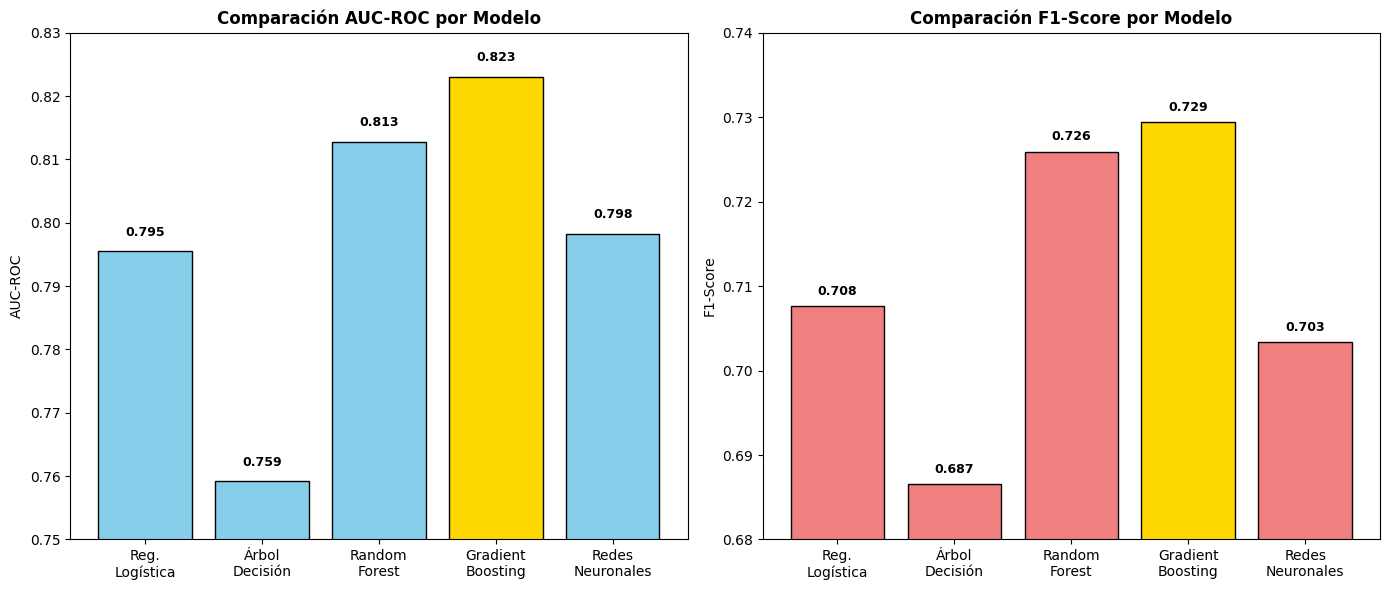


ANÁLISIS DE DIFERENCIAS
Mejor AUC-ROC: Gradient Boosting (0.823014)
Mejor F1-Score: Gradient Boosting (0.729385)

Gradient Boosting es el mejor en ambas métricas

Diferencia entre mejor y segundo mejor:
AUC-ROC: 0.010265
F1-Score: 0.003449


In [ ]:
print("=" * 80)
print("COMPARACIÓN FINAL DE TODOS LOS MODELOS")
print("=" * 80)

# Resultados consolidados de todos los modelos (métricas CV)
resultados_finales = {
    'Modelo': [
        'Regresión Logística',
        'Árbol de Decisión',
        'Random Forest',
        'Gradient Boosting',
        'Redes Neuronales'
    ],
    'F1_CV': [0.707635, 0.686562, 0.725936, 0.729385, 0.703385],
    'AUC_CV': [0.795499, 0.759200, 0.812749, 0.823014, 0.798303],
    'Mejores_Hiperparámetros': [
        'C=10, penalty=l2',
        'max_depth=5, min_samples_split=20, criterion=gini',
        'n_estimators=200, max_depth=None, criterion=gini',
        'n_estimators=200, learning_rate=0.1, max_depth=3',
        'hidden_layer_sizes=(100,), alpha=0.0001, lr=0.001'
    ]
}

# Crear DataFrame resumen
df_resumen = pd.DataFrame(resultados_finales)

print("TABLA RESUMEN DE RESULTADOS")
print("=" * 60)
print(df_resumen[['Modelo', 'F1_CV', 'AUC_CV']].to_string(index=False))

print(f"\nRANKING POR AUC-ROC (métrica de Kaggle):")
print("=" * 50)
df_ranking_auc = df_resumen.sort_values('AUC_CV', ascending=False)
for i, (idx, row) in enumerate(df_ranking_auc.iterrows(), 1):
    print(f"{i}. {row['Modelo']}: AUC = {row['AUC_CV']:.6f}")

print(f"\nRANKING POR F1-SCORE:")
print("=" * 30)
df_ranking_f1 = df_resumen.sort_values('F1_CV', ascending=False)
for i, (idx, row) in enumerate(df_ranking_f1.iterrows(), 1):
    print(f"{i}. {row['Modelo']}: F1 = {row['F1_CV']:.6f}")

# Visualización comparativa
print(f"\nGRÁFICO COMPARATIVO")
print("=" * 30)

plt.figure(figsize=(14, 6))

# Subplot 1: AUC-ROC
plt.subplot(1, 2, 1)
modelos_cortos = ['Reg.\nLogística', 'Árbol\nDecisión', 'Random\nForest', 'Gradient\nBoosting', 'Redes\nNeuronales']
auc_scores = df_resumen['AUC_CV'].values
colors_auc = ['gold' if x == max(auc_scores) else 'skyblue' for x in auc_scores]

bars1 = plt.bar(modelos_cortos, auc_scores, color=colors_auc, edgecolor='black', linewidth=1)
plt.title('Comparación AUC-ROC por Modelo', fontsize=12, fontweight='bold')
plt.ylabel('AUC-ROC', fontsize=10)
plt.ylim(0.75, 0.83)

# Agregar valores en las barras
for bar, score in zip(bars1, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Subplot 2: F1-Score
plt.subplot(1, 2, 2)
f1_scores = df_resumen['F1_CV'].values
colors_f1 = ['gold' if x == max(f1_scores) else 'lightcoral' for x in f1_scores]

bars2 = plt.bar(modelos_cortos, f1_scores, color=colors_f1, edgecolor='black', linewidth=1)
plt.title('Comparación F1-Score por Modelo', fontsize=12, fontweight='bold')
plt.ylabel('F1-Score', fontsize=10)
plt.ylim(0.68, 0.74)

# Agregar valores en las barras
for bar, score in zip(bars2, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis de diferencias
print(f"\nANÁLISIS DE DIFERENCIAS")
print("=" * 40)
mejor_auc = max(auc_scores)
mejor_f1 = max(f1_scores)
modelo_mejor_auc = df_resumen.loc[df_resumen['AUC_CV'].idxmax(), 'Modelo']
modelo_mejor_f1 = df_resumen.loc[df_resumen['F1_CV'].idxmax(), 'Modelo']

print(f"Mejor AUC-ROC: {modelo_mejor_auc} ({mejor_auc:.6f})")
print(f"Mejor F1-Score: {modelo_mejor_f1} ({mejor_f1:.6f})")

if modelo_mejor_auc == modelo_mejor_f1:
    print(f"\n{modelo_mejor_auc} es el mejor en ambas métricas")
else:
    print(f"\nDiferentes modelos lideran cada métrica")

print(f"\nDiferencia entre mejor y segundo mejor:")
auc_sorted = sorted(auc_scores, reverse=True)
f1_sorted = sorted(f1_scores, reverse=True)
print(f"AUC-ROC: {auc_sorted[0] - auc_sorted[1]:.6f}")
print(f"F1-Score: {f1_sorted[0] - f1_sorted[1]:.6f}")

# 8.Seleccion del modelo final

In [ ]:
# Modelo seleccionado: Gradient Boosting
print("MODELO FINAL SELECCIONADO: GRADIENT BOOSTING")
print("=" * 60)
print("Justificación:")
print("- Mejor AUC-ROC: 0.823014 (métrica de evaluación en Kaggle)")
print("- Mejor F1-Score: 0.729385")
print("- Lidera ambas métricas de forma consistente")

# Configuración final del modelo
modelo_final = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    random_state=42
)

print(f"\nCONFIGURACIÓN FINAL:")
print("=" * 30)
print(f"n_estimators: 200")
print(f"learning_rate: 0.1")
print(f"max_depth: 3")
print(f"min_samples_split: 5")
print(f"random_state: 42")

# Entrenamiento del modelo final con todos los datos de entrenamiento
print(f"\nENTRENAMIENTO DEL MODELO FINAL")
print("=" * 50)
X_final = df_clean.drop(columns='opinion').values
y_final = df_clean['opinion'].values

modelo_final.fit(X_final, y_final)
print(f"Modelo entrenado con {X_final.shape[0]} muestras y {X_final.shape[1]} características")
print(f"Distribución de clases: {np.bincount(y_final)}")

# Validación final con el conjunto de validación usado en todos los modelos
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_final, y_final, test_size=0.2, stratify=y_final, random_state=42
)

modelo_final.fit(X_train_final, y_train_final)
y_pred_final = modelo_final.predict(X_val_final)
y_prob_final = modelo_final.predict_proba(X_val_final)[:, 1]

# Métricas finales
metricas_finales = {
    'accuracy': accuracy_score(y_val_final, y_pred_final),
    'precision': precision_score(y_val_final, y_pred_final),
    'recall': recall_score(y_val_final, y_pred_final),
    'f1_score': f1_score(y_val_final, y_pred_final),
    'auc_roc': roc_auc_score(y_val_final, y_prob_final)
}

print(f"\nMÉTRICAS FINALES EN VALIDACIÓN")
print("=" * 40)
for metrica, valor in metricas_finales.items():
    print(f"{metrica.upper()}: {valor:.6f}")

# Matriz de confusión final
cm_final = confusion_matrix(y_val_final, y_pred_final)
print(f"\nMATRIZ DE CONFUSIÓN FINAL")
print("=" * 35)
print(cm_final)

MODELO FINAL SELECCIONADO: GRADIENT BOOSTING
Justificación:
- Mejor AUC-ROC: 0.823014 (métrica de evaluación en Kaggle)
- Mejor F1-Score: 0.729385
- Lidera ambas métricas de forma consistente

CONFIGURACIÓN FINAL:
n_estimators: 200
learning_rate: 0.1
max_depth: 3
min_samples_split: 5
random_state: 42

ENTRENAMIENTO DEL MODELO FINAL
Modelo entrenado con 3602 muestras y 74 características
Distribución de clases: [1824 1778]

MÉTRICAS FINALES EN VALIDACIÓN
ACCURACY: 0.761442
PRECISION: 0.764368
RECALL: 0.747191
F1_SCORE: 0.755682
AUC_ROC: 0.833365

MATRIZ DE CONFUSIÓN FINAL
[[283  82]
 [ 90 266]]


# 9.Predicciones para Kaggle

In [ ]:
# Verificar si ya se aplicaron las transformaciones
if 'director_grouped' in df_test.columns:
    print("Las transformaciones ya fueron aplicadas anteriormente.")
    print("Usando dataset de test ya procesado...")

    # Usar el dataset ya procesado
    df_test_clean = df_test.copy()

    # Convertir booleanas si es necesario
    bool_cols = df_test_clean.select_dtypes('bool').columns
    if len(bool_cols) > 0:
        df_test_clean[bool_cols] = df_test_clean[bool_cols].astype(int)

    # Eliminar columnas de texto
    df_test_clean.drop(columns=[
        'overview', 'keywords', 'original_title', 'release_date'
    ], inplace=True, errors='ignore')

else:
    # Aplicar transformaciones por primera vez
    print("PREPARACIÓN DEL DATASET DE TEST")
    print("=" * 50)

    print("Aplicando preprocesamiento al dataset de test...")

    # Aplicar agrupación de directores
    print("Aplicando agrupación de directores...")
    df_test['director_grouped'] = df_test['director'].replace(rare_directors_list, 'Other')
    df_test.drop(columns=['director'], inplace=True)

    # Aplicar codificación categórica
    print("Aplicando codificación categórica...")
    categorical_cols = ['original_language', 'status', 'main_genre_top10', 'director_grouped']
    df_test_encoded = pd.get_dummies(df_test, columns=categorical_cols, drop_first=True)

    # Crear df_test_clean
    df_test_clean = df_test_encoded.copy()

    # Convertir columnas booleanas a enteros
    bool_cols = df_test_clean.select_dtypes('bool').columns
    df_test_clean[bool_cols] = df_test_clean[bool_cols].astype(int)

    # Eliminar columnas de texto libre
    df_test_clean.drop(columns=[
        'overview', 'keywords', 'original_title', 'release_date'
    ], inplace=True, errors='ignore')

print(f"Shape del test procesado: {df_test_clean.shape}")

# Asegurar que test tenga las mismas columnas que train
print("\nAlineando columnas con dataset de entrenamiento...")
train_columns = df_clean.drop(columns='opinion').columns.tolist()
test_columns = df_test_clean.drop(columns='id').columns.tolist()

# Verificar columnas faltantes o extras
missing_in_test = set(train_columns) - set(test_columns)
extra_in_test = set(test_columns) - set(train_columns)

if missing_in_test:
    print(f"Columnas faltantes en test: {missing_in_test}")
    for col in missing_in_test:
        df_test_clean[col] = 0

if extra_in_test:
    print(f"Columnas extra en test: {extra_in_test}")
    df_test_clean.drop(columns=list(extra_in_test), inplace=True)

# Reordenar columnas para coincidir con entrenamiento
X_test_final = df_test_clean[['id'] + train_columns].copy()
ids_test = X_test_final['id'].values
X_test_final = X_test_final.drop(columns='id').values

print(f"Shape final para predicción: {X_test_final.shape}")
print(f"IDs de test: {len(ids_test)} registros")

# Generar predicciones
print(f"\nGENERANDO PREDICCIONES")
print("=" * 35)

# Entrenar modelo final con todos los datos de entrenamiento
modelo_final_kaggle = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    random_state=42
)

X_train_all = df_clean.drop(columns='opinion').values
y_train_all = df_clean['opinion'].values

print("Entrenando modelo final con todos los datos de entrenamiento...")
modelo_final_kaggle.fit(X_train_all, y_train_all)

print("Generando predicciones de probabilidad...")
y_pred_proba_kaggle = modelo_final_kaggle.predict_proba(X_test_final)[:, 1]

print("Generando predicciones de clase...")
y_pred_kaggle = modelo_final_kaggle.predict(X_test_final)

# Crear archivo de submission
print(f"\nCREANDO ARCHIVO DE SUBMISSION")
print("=" * 40)

submission = pd.DataFrame({
    'id': ids_test,
    'opinion': y_pred_proba_kaggle
})

print("Primeras 10 predicciones:")
print(submission.head(10))

print(f"\nEstadísticas de las predicciones:")
print(f"Mínimo: {y_pred_proba_kaggle.min():.6f}")
print(f"Máximo: {y_pred_proba_kaggle.max():.6f}")
print(f"Media: {y_pred_proba_kaggle.mean():.6f}")
print(f"Mediana: {np.median(y_pred_proba_kaggle):.6f}")

# Distribución de predicciones de clase
print(f"\nDistribución de predicciones de clase:")
print(f"Clase 0: {(y_pred_kaggle == 0).sum()} ({(y_pred_kaggle == 0).mean():.1%})")
print(f"Clase 1: {(y_pred_kaggle == 1).sum()} ({(y_pred_kaggle == 1).mean():.1%})")

# Guardar archivo
submission_filename = 'submission_gradient_boosting.csv'
submission.to_csv(submission_filename, index=False)
print(f"\nArchivo guardado: {submission_filename}")
print(f"Formato: {submission.shape[0]} filas, {submission.shape[1]} columnas")

PREPARACIÓN DEL DATASET DE TEST
Aplicando preprocesamiento al dataset de test...
Aplicando agrupación de directores...
Aplicando codificación categórica...
Shape del test procesado: (1201, 462)

Alineando columnas con dataset de entrenamiento...
Columnas faltantes en test: {'original_language_no', 'original_language_ps', 'original_language_vi', 'original_language_ar', 'original_language_el', 'original_language_da', 'original_language_is', 'original_language_sl', 'original_language_ky', 'director_grouped_Stephen Frears', 'original_language_ta', 'original_language_tr', 'original_language_id', 'original_language_hu', 'original_language_fa', 'original_language_te', 'original_language_nb', 'original_language_pl', 'original_language_cs', 'original_language_xx'}
Columnas extra en test: {'director_grouped_Sean Durkin', 'director_grouped_Darren Press', 'director_grouped_Fred Savage', 'director_grouped_Daniel Barber', 'director_grouped_Josh Trank', 'director_grouped_Lori Silverbush', 'director_g

In [ ]:
# ============================================================================
# PREDICCIONES CON RANDOM FOREST PARA KAGGLE
# ============================================================================

print("=" * 80)
print("GENERACIÓN DE PREDICCIONES CON RANDOM FOREST")
print("=" * 80)

# Modelo Random Forest con la configuración óptima encontrada
modelo_rf_kaggle = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    criterion='gini',
    random_state=42,
    n_jobs=-1
)

print("CONFIGURACIÓN RANDOM FOREST:")
print("=" * 40)
print(f"n_estimators: 200")
print(f"max_depth: None")
print(f"min_samples_split: 5")
print(f"criterion: gini")
print(f"random_state: 42")

# Entrenar con todos los datos de entrenamiento
X_train_all = df_clean.drop(columns='opinion').values
y_train_all = df_clean['opinion'].values

print(f"\nEntrenando Random Forest con todos los datos...")
modelo_rf_kaggle.fit(X_train_all, y_train_all)

# Usar el mismo X_test_final que ya preparamos
print(f"Generando predicciones con Random Forest...")
y_pred_proba_rf = modelo_rf_kaggle.predict_proba(X_test_final)[:, 1]
y_pred_rf = modelo_rf_kaggle.predict(X_test_final)

# Crear archivo de submission para Random Forest
print(f"\nCREANDO SUBMISSION RANDOM FOREST")
print("=" * 45)

submission_rf = pd.DataFrame({
    'id': ids_test,
    'opinion': y_pred_proba_rf
})

print("Primeras 10 predicciones Random Forest:")
print(submission_rf.head(10))

print(f"\nEstadísticas de las predicciones Random Forest:")
print(f"Mínimo: {y_pred_proba_rf.min():.6f}")
print(f"Máximo: {y_pred_proba_rf.max():.6f}")
print(f"Media: {y_pred_proba_rf.mean():.6f}")
print(f"Mediana: {np.median(y_pred_proba_rf):.6f}")

print(f"\nDistribución de predicciones de clase:")
print(f"Clase 0: {(y_pred_rf == 0).sum()} ({(y_pred_rf == 0).mean():.1%})")
print(f"Clase 1: {(y_pred_rf == 1).sum()} ({(y_pred_rf == 1).mean():.1%})")

# Comparación con Gradient Boosting
print(f"\nCOMPARACIÓN CON GRADIENT BOOSTING")
print("=" * 45)
correlacion = np.corrcoef(y_pred_proba_kaggle, y_pred_proba_rf)[0,1]
print(f"Correlación entre predicciones: {correlacion:.6f}")
print(f"Diferencia promedio absoluta: {np.mean(np.abs(y_pred_proba_kaggle - y_pred_proba_rf)):.6f}")

# Guardar archivo Random Forest
submission_rf_filename = 'submission_random_forest.csv'
submission_rf.to_csv(submission_rf_filename, index=False)
print(f"\nArchivo Random Forest guardado: {submission_rf_filename}")
print(f"Formato: {submission_rf.shape[0]} filas, {submission_rf.shape[1]} columnas")

GENERACIÓN DE PREDICCIONES CON RANDOM FOREST
CONFIGURACIÓN RANDOM FOREST:
n_estimators: 200
max_depth: None
min_samples_split: 5
criterion: gini
random_state: 42

Entrenando Random Forest con todos los datos...
Generando predicciones con Random Forest...

CREANDO SUBMISSION RANDOM FOREST
Primeras 10 predicciones Random Forest:
   id   opinion
0   0  0.936994
1   1  0.536909
2   2  0.691681
3   3  0.984917
4   4  0.715351
5   5  0.914500
6   6  0.730375
7   7  0.776121
8   8  0.333313
9   9  0.430387

Estadísticas de las predicciones Random Forest:
Mínimo: 0.023720
Máximo: 0.985000
Media: 0.511803
Mediana: 0.495494

Distribución de predicciones de clase:
Clase 0: 610 (50.8%)
Clase 1: 591 (49.2%)

COMPARACIÓN CON GRADIENT BOOSTING
Correlación entre predicciones: 0.930462
Diferencia promedio absoluta: 0.083043

Archivo Random Forest guardado: submission_random_forest.csv
Formato: 1201 filas, 2 columnas


In [ ]:
# ============================================================================
# 9. ENSEMBLE - GRADIENT BOOSTING + RANDOM FOREST
# ============================================================================

# Combinamos las predicciones ya generadas
y_pred_ensemble = (y_pred_proba_kaggle + y_pred_proba_rf) / 2

submission_ensemble = pd.DataFrame({
    'id': ids_test,
    'opinion': y_pred_ensemble
})

submission_ensemble.to_csv('submission_ensemble.csv', index=False)
print("Ensemble generado: submission_ensemble.csv")

Ensemble generado: submission_ensemble.csv


In [ ]:
# ============================================================================
# 10. ENSEMBLE PONDERADO - GRADIENT BOOSTING + RANDOM FOREST
# ============================================================================

print("=" * 80)
print("ENSEMBLE PONDERADO - GRADIENT BOOSTING + RANDOM FOREST")
print("=" * 80)

# Configuración de pesos para ensemble ponderado
pesos = [
    (0.8, 0.2),   # 80% GB, 20% RF
    (0.9, 0.1),   # 90% GB, 10% RF
    (0.75, 0.25), # 75% GB, 25% RF
    (0.85, 0.15), # 85% GB, 15% RF
    (0.95, 0.05)  # 95% GB, 5% RF
]

print(f"GENERANDO {len(pesos)} ENSEMBLES PONDERADOS")
print("=" * 50)

submissions_generadas = []

for i, (peso_gb, peso_rf) in enumerate(pesos, 1):
    print(f"\nEnsemble {i}: {peso_gb:.0%} GB + {peso_rf:.0%} RF")

    # Combinar predicciones con pesos
    y_pred_weighted = peso_gb * y_pred_proba_kaggle + peso_rf * y_pred_proba_rf

    # Crear submission
    submission_weighted = pd.DataFrame({
        'id': ids_test,
        'opinion': y_pred_weighted
    })

    # Generar nombre de archivo
    filename = f'submission_ensemble_{int(peso_gb*100)}_{int(peso_rf*100)}.csv'

    # Guardar archivo
    submission_weighted.to_csv(filename, index=False)
    submissions_generadas.append(filename)

    # Estadísticas de las predicciones
    print(f"Archivo generado: {filename}")
    print(f"Media: {y_pred_weighted.mean():.6f}")
    print(f"Rango: [{y_pred_weighted.min():.6f}, {y_pred_weighted.max():.6f}]")

print(f"\nSUMMARY DE SUBMISSIONS GENERADAS")
print("=" * 45)
for i, filename in enumerate(submissions_generadas, 1):
    peso_gb = pesos[i-1][0]
    peso_rf = pesos[i-1][1]
    print(f"{i}. {filename}")

ENSEMBLE PONDERADO - GRADIENT BOOSTING + RANDOM FOREST
GENERANDO 5 ENSEMBLES PONDERADOS

Ensemble 1: 80% GB + 20% RF
Archivo generado: submission_ensemble_80_20.csv
Media: 0.508571
Rango: [0.023144, 0.988345]

Ensemble 2: 90% GB + 10% RF
Archivo generado: submission_ensemble_90_10.csv
Media: 0.508167
Rango: [0.021605, 0.991678]

Ensemble 3: 75% GB + 25% RF
Archivo generado: submission_ensemble_75_25.csv
Media: 0.508773
Rango: [0.023914, 0.987279]

Ensemble 4: 85% GB + 15% RF
Archivo generado: submission_ensemble_85_15.csv
Media: 0.508369
Rango: [0.022374, 0.990011]

Ensemble 5: 95% GB + 5% RF
Archivo generado: submission_ensemble_95_5.csv
Media: 0.507964
Rango: [0.020835, 0.993345]

SUMMARY DE SUBMISSIONS GENERADAS
1. submission_ensemble_80_20.csv
2. submission_ensemble_90_10.csv
3. submission_ensemble_75_25.csv
4. submission_ensemble_85_15.csv
5. submission_ensemble_95_5.csv


In [ ]:
# ============================================================================
# 11. REGRESIÓN LOGÍSTICA OPTIMIZADA PARA KAGGLE
# ============================================================================

print("=" * 80)
print("REGRESIÓN LOGÍSTICA OPTIMIZADA - PREDICCIONES KAGGLE")
print("=" * 80)

# Configuración óptima encontrada en CV
modelo_lr_kaggle = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=10,
        penalty='l2',
        solver='saga',
        max_iter=1000,
        random_state=42
    )
)

print("CONFIGURACIÓN REGRESIÓN LOGÍSTICA:")
print("=" * 45)
print("C: 10")
print("penalty: l2")
print("solver: saga")
print("CV AUC: 0.795499")
print("CV F1: 0.707635")

# Entrenar con todos los datos de entrenamiento
X_train_all = df_clean.drop(columns='opinion').values
y_train_all = df_clean['opinion'].values

print(f"\nEntrenando Regresión Logística...")
modelo_lr_kaggle.fit(X_train_all, y_train_all)

# Generar predicciones
print(f"Generando predicciones...")
y_pred_proba_lr = modelo_lr_kaggle.predict_proba(X_test_final)[:, 1]
y_pred_lr = modelo_lr_kaggle.predict(X_test_final)

# Crear submission
print(f"\nCREANDO SUBMISSION REGRESIÓN LOGÍSTICA")
print("=" * 50)

submission_lr = pd.DataFrame({
    'id': ids_test,
    'opinion': y_pred_proba_lr
})

print("Primeras 10 predicciones:")
print(submission_lr.head(10))

print(f"\nEstadísticas de predicciones:")
print(f"Media: {y_pred_proba_lr.mean():.6f}")
print(f"Rango: [{y_pred_proba_lr.min():.6f}, {y_pred_proba_lr.max():.6f}]")

print(f"\nDistribución de clases:")
print(f"Clase 0: {(y_pred_lr == 0).sum()} ({(y_pred_lr == 0).mean():.1%})")
print(f"Clase 1: {(y_pred_lr == 1).sum()} ({(y_pred_lr == 1).mean():.1%})")

# Guardar archivo
submission_lr_filename = 'submission_logistic_regression.csv'
submission_lr.to_csv(submission_lr_filename, index=False)

print(f"\nArchivo generado: {submission_lr_filename}")

REGRESIÓN LOGÍSTICA OPTIMIZADA - PREDICCIONES KAGGLE
CONFIGURACIÓN REGRESIÓN LOGÍSTICA:
C: 10
penalty: l2
solver: saga
CV AUC: 0.795499
CV F1: 0.707635

Entrenando Regresión Logística...
Generando predicciones...

CREANDO SUBMISSION REGRESIÓN LOGÍSTICA
Primeras 10 predicciones:
   id   opinion
0   0  0.999622
1   1  0.033527
2   2  0.684314
3   3  0.994168
4   4  0.030798
5   5  0.999996
6   6  0.635314
7   7  0.647764
8   8  0.427603
9   9  0.046962

Estadísticas de predicciones:
Media: 0.469923
Rango: [0.001333, 0.999999]

Distribución de clases:
Clase 0: 703 (58.5%)
Clase 1: 498 (41.5%)

Archivo generado: submission_logistic_regression.csv
